# descriptive.ipynb

This notebook calculated descriptive statistics in detail. The main notebook reports just a summary.

The `display_summary_table` and `plot_descriptive` functions below are called from the main notebook.

<br>
<br>

In [1]:
from IPython.display import display,Markdown #,HTML
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import pandas as pd
from scipy.stats import pearsonr
import scipy.stats as st
import sympy
from sklearn.datasets import load_iris
import scipy.stats as st


def display_title(s, pref='Figure', num=1, center=False):
    ctag = 'center' if center else 'p'
    s    = f'<{ctag}><span style="font-size: 1.2em;"><b>{pref} {num}</b>: {s}</span></{ctag}>'
    if pref=='Figure':
        s = f'{s}<br><br>'
    else:
        s = f'<br><br>{s}'
    display( Markdown(s) )



Below the previously developed `parse_data.ipynb` notebook is run. See that notebook for details.

In [2]:
%run parse_data.ipynb

df.describe()

,age,Medu,Fedu,travel,study,failures,freetime,go_out,absences,Grade
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.235443,3.108861,5.708861,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.998862,1.113278,8.003096,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,3.000000,3.000000,4.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,4.000000,4.000000,8.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,75.000000,20.000000


To create a custom display of descriptive statistics, let's first define functions that will calculate central tendency and dispersion metrics.

Refer also to [this notebook](https://github.com/0todd0000/OpenBook-DataAnalysisPracticeInPythonAndJupyter/blob/master/Lessons/Lesson04/5-Examples/DescriptiveStatsExamples.ipynb) for details regarding how create custom descriptive statistics tables.

In [3]:
def central(x, print_output=True):
    x0     = np.mean( x )
    x1     = np.median( x )
    x2     = stats.mode( x ).mode
    x3     = st.skew(x)
    x4     = st.kurtosis(x)
    return x0, x1, x2, x3, x4

def dispersion(x, print_output=True):
    y0 = np.std( x ) # standard deviation
    y1 = np.min( x )  # minimum
    y2 = np.max( x )  # maximum
    y3 = y2 - y1      # range
    y4 = np.percentile( x, 25 ) # 25th percentile (i.e., lower quartile)
    y5 = np.percentile( x, 75 ) # 75th percentile (i.e., upper quartile)
    y6 = y5 - y4 # inter-quartile range
    return y0,y1,y2,y3,y4,y5,y6

<br>

Let's now assemble and display a central tendency table:

</br>

In [4]:
def display_central_tendency_table(num=1):
    display_title('Central tendency summary statistics.', pref='Table', num=num, center=False)
    df_central = df.apply(lambda x: central(x), axis=0)
    round_dict = 3
    df_central = df_central.round( round_dict )
    row_labels = 'mean', 'median', 'mode', 'skew', 'kurtosis'
    df_central.index = row_labels
    display( df_central )

display_central_tendency_table(num=1)

<br><br><p><span style="font-size: 1.2em;"><b>Table 1</b>: Central tendency summary statistics.</span></p>

,age,Medu,Fedu,travel,study,failures,freetime,go_out,absences,Grade
mean,16.696,2.749,2.522,1.448,2.035,0.334,3.235,3.109,5.709,10.415
median,17.000,3.000,2.000,1.000,2.000,0.000,3.000,3.000,4.000,11.000
mode,16.000,4.000,2.000,1.000,2.000,0.000,3.000,3.000,0.000,10.000
skew,0.464,-0.317,-0.032,1.601,0.630,2.378,-0.163,0.116,3.658,-0.730
kurtosis,-0.016,-1.091,-1.199,2.299,-0.029,4.926,-0.313,-0.776,21.430,0.383


<br>

Let's repeat for a dispersion table:

</br>

In [5]:
def display_dispersion_table(num=1):
    display_title('Dispersion summary statistics.', pref='Table', num=num, center=False)
    round_dict            = 3
    df_dispersion         = df.apply(lambda x: dispersion(x), axis=0).round( round_dict )
    row_labels_dispersion = 'st.dev.', 'min', 'max', 'range', '25th', '75th', 'IQR'
    df_dispersion.index   = row_labels_dispersion
    display( df_dispersion )

display_dispersion_table(num=2)


<br><br><p><span style="font-size: 1.2em;"><b>Table 2</b>: Dispersion summary statistics.</span></p>

,age,Medu,Fedu,travel,study,failures,freetime,go_out,absences,Grade
st.dev.,1.274,1.093,1.087,0.697,0.838,0.743,0.998,1.112,7.993,4.576
min,15.000,0.000,0.000,1.000,1.000,0.000,1.000,1.000,0.000,0.000
max,22.000,4.000,4.000,4.000,4.000,3.000,5.000,5.000,75.000,20.000
range,7.000,4.000,4.000,3.000,3.000,3.000,4.000,4.000,75.000,20.000
25th,16.000,2.000,2.000,1.000,1.000,0.000,3.000,2.000,0.000,8.000
75th,18.000,4.000,3.000,2.000,2.000,0.000,4.000,4.000,8.000,14.000
IQR,2.000,2.000,1.000,1.000,1.000,0.000,1.000,2.000,8.000,6.000


Let's save the variables in easier-to-use variable names:

In [6]:
y    = df['Grade']

age  = df['age']
medu = df['Medu']
fedu = df['Fedu']
ttime  =df['travel']
stime  =df['study']
fail   =df['failures']
ftime  =df['freetime']
go     =df['go_out']
absent =df['absences']

columns=df.columns

Let's create scatterplots for the DV (quality) vs. each of the three IVs (acid, density, sugar):

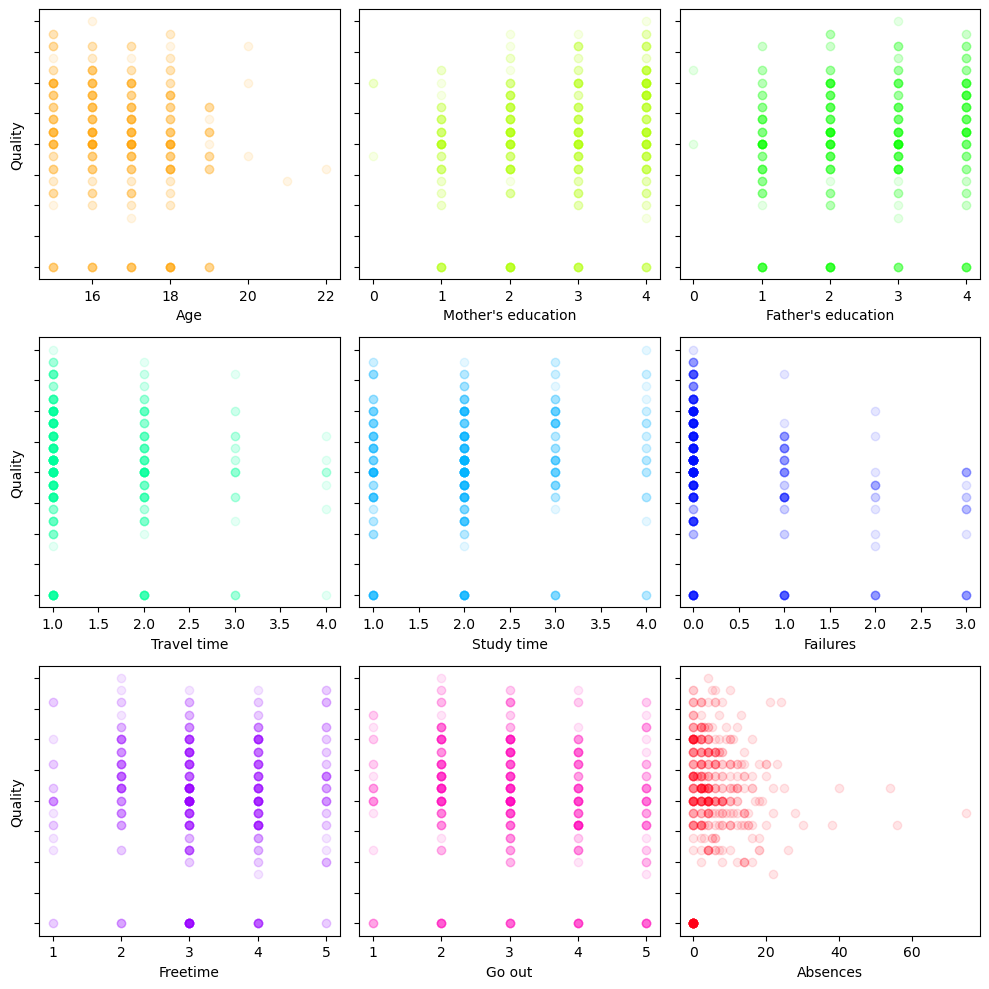

In [7]:

fig,axs = plt.subplots( 3, 3, figsize=(10,10), tight_layout=True )
axs[0, 0].scatter( age,    y, alpha=0.1, color=cm.hsv(1/9) )
axs[0, 1].scatter( medu ,  y, alpha=0.1, color=cm.hsv(2/9) )
axs[0, 2].scatter( fedu,   y, alpha=0.1, color=cm.hsv(3/9) )
axs[1, 0].scatter( ttime,  y, alpha=0.1, color=cm.hsv(4/9) )
axs[1, 1].scatter( stime,  y, alpha=0.1, color=cm.hsv(5/9) )
axs[1, 2].scatter( fail,   y, alpha=0.1, color=cm.hsv(6/9) )
axs[2, 0].scatter( ftime,  y, alpha=0.1, color=cm.hsv(7/9) )
axs[2, 1].scatter( go,     y, alpha=0.1, color=cm.hsv(8/9) )
axs[2, 2].scatter( absent, y, alpha=0.1, color=cm.hsv(9/9) )


xlabels = 'Age', "Mother's education", "Father's education", 'Travel time', 'Study time', 'Failures', 'Freetime', 'Go out', 'Absences'  

for a, s in zip(axs.flat, xlabels):
    a.set_xlabel(s)
axs[0, 0].set_ylabel('Quality')
axs[1, 0].set_ylabel('Quality')
axs[2, 0].set_ylabel('Quality')
for a, s in zip(axs.flat, xlabels):
        a.set_yticklabels([])
plt.show()


Next let's add regression lines and correlation coefficients to each plot:

In [8]:
def corrcoeff(x, y):
    r = np.corrcoef(x, y)[0,1]
    return r

def plot_regression_line(ax, x, y, **kwargs):
    a,b   = np.polyfit(x, y, deg=1)
    x0,x1 = min(x), max(x)
    y0,y1 = a*x0 + b, a*x1 + b
    ax.plot([x0,x1], [y0,y1], **kwargs)


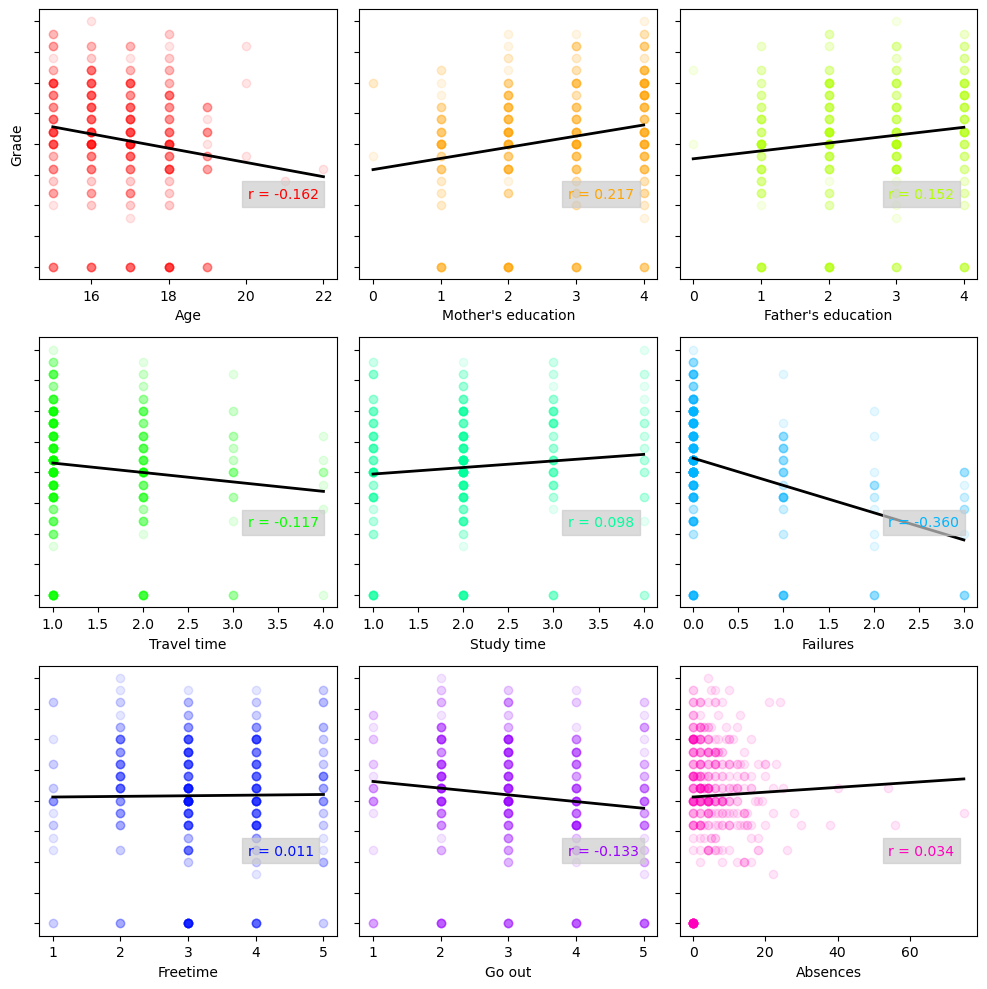

In [9]:
    
fig,axs = plt.subplots( 3, 3, figsize=(10,10), tight_layout=True )
ivs     = [age, medu, fedu, ttime, stime, fail, ftime, go, absent]
colors = [cm.hsv(i/9) for i in range (0,9)]

for ax,x,c in zip(axs.flat, ivs, colors):
    ax.scatter( x, y, alpha=0.1, color=c )
    plot_regression_line(ax, x, y, color='k', ls='-', lw=2)
    r   = corrcoeff(x, y)
    ax.text(0.7, 0.3, f'r = {r:.3f}', color=c, transform=ax.transAxes, bbox=dict(color='0.8', alpha=0.7))

[ax.set_xlabel(s) for ax,s in zip(axs.flat,xlabels)]
axs[2, 2].set_xticks([0, 20, 40, 60])
axs[0, 0].set_ylabel('Grade')
for a, s in zip(axs.flat, xlabels):
        a.set_yticklabels([])
plt.show()

The correlation coefficients are all relatively low, suggesting no clear linear correlation between the DV and IVs.

However, it appears that many data are inhibited from showing realistic data by the failure grade (grade = 0). Let's plot all of these again without data with grade = 0, along with linear regression trends. Let's implement the test of no correlation too, in order to see if the correlation coefficient is not 

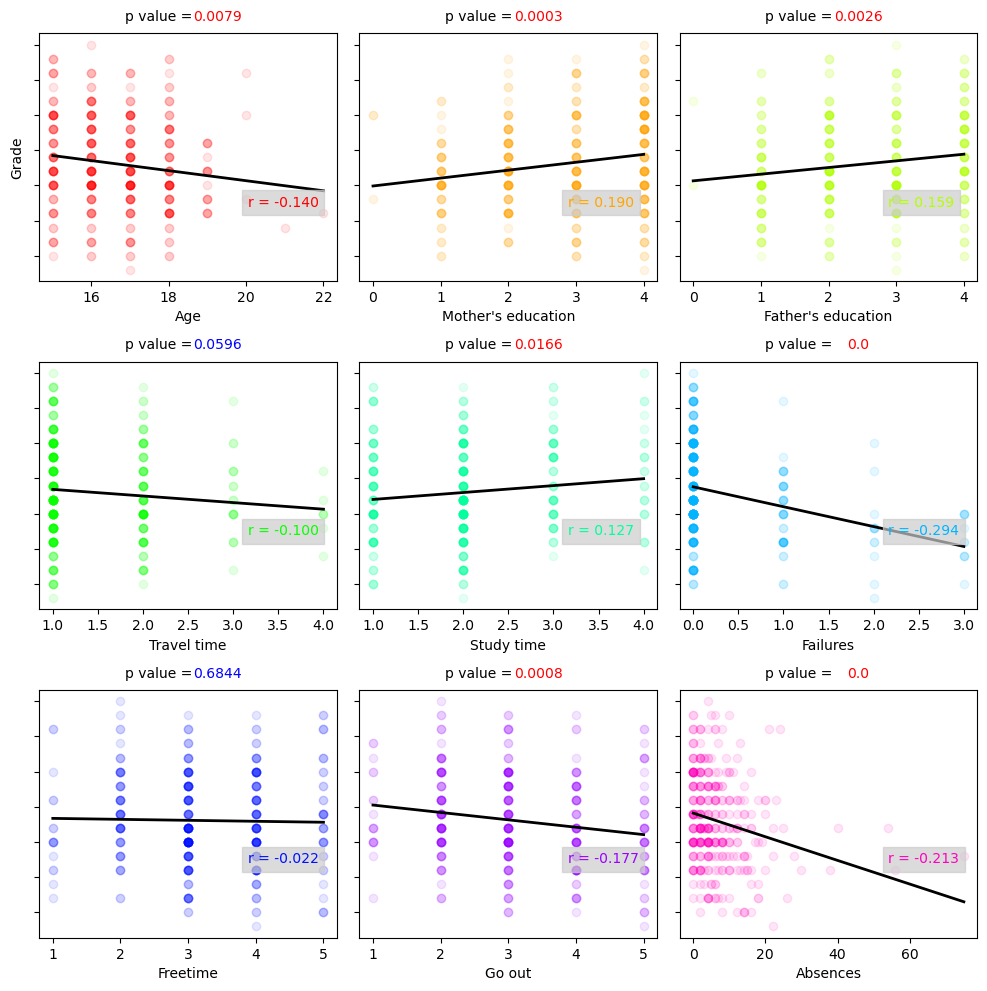

In [10]:
i_0       = y ==0
i_high    = y > 0
r2 = []
p2 = []

fig,axs = plt.subplots( 3, 3, figsize=(10,10), tight_layout=True )
i       = [age, medu, fedu, ttime, stime, fail, ftime, go, absent]

for ax,x,c in zip(axs.flat, ivs, colors):
    ax.scatter(x[i_high], y[i_high], alpha=0.1, color=c )
    plot_regression_line(ax, x[i_high], y[i_high], color='k', ls='-', lw=2)
    res = pearsonr(x[i_high], y[i_high])
    r = res[0]
    ax.text(0.7, 0.3, f'r = {r:.3f}', color=c, transform=ax.transAxes, bbox=dict(color='0.8', alpha=0.7))
    r2.append(round(res[0], 4))
    p2.append(round(res[1], 4))

[ax.set_xlabel(s) for ax,s in zip(axs.flat,xlabels)]
[ax.text(0.6, 1.05, p2[i] , ha='center', transform=ax.transAxes, color = "r" if p2[i] < 0.05 else "b") for i, (ax ,s) in enumerate(zip(axs.flat,xlabels))]
[ax.text(0.4, 1.05, "p value =" , ha='center', transform=ax.transAxes) for ax,s in zip(axs.flat,xlabels)]
axs[2, 2].set_xticks([0, 20, 40, 60])
axs[0, 0].set_ylabel('Grade')
for a, s in zip(axs.flat, xlabels):
        a.set_yticklabels([])
plt.show()

The linear trend lines and the p-value above each figure in the 9 figures above shows that:

- Correlation between grade and, Travel time to school and Freetime are not significant.
- Grade appears to increase with increment in Parent's education and study time.
- Grade appears to decrease with decrement in Age, Failures, Going out, and Absences.
- Failures and Absences have relatively strong relation, above 0.2, with grade.

The two factor, Failures and Absences are significant. To see whether it's general tendency, let's see their average for each grade.

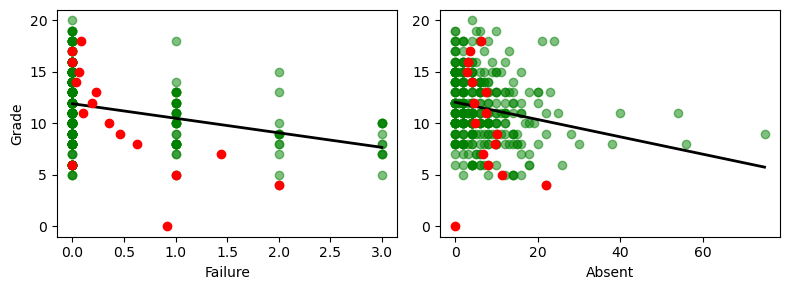

In [11]:
fig,axs = plt.subplots( 1, 2, figsize=(8,3), tight_layout=True )

for ax,x,c in zip(axs.flat, [fail, absent], colors):
    ax.scatter(x[i_high], y[i_high], alpha=0.5, color='g' )
    plot_regression_line(ax, x[i_high], y[i_high], color='k', ls='-', lw=2)
    
[axs[0].plot(fail[y==q].mean(), q, 'ro')  for q in range (0, 19)]
[axs[1].plot(absent[y==q].mean(), q, 'ro')  for q in range (0, 19)]
axs[0].set_xlabel('Failure')
axs[1].set_xlabel('Absent')
axs[0].set_ylabel('Grade')
plt.show()


These analyses show that the trends associated with just the means are unclear.

Let's now assemble all results into a single figure for reporting purposes:

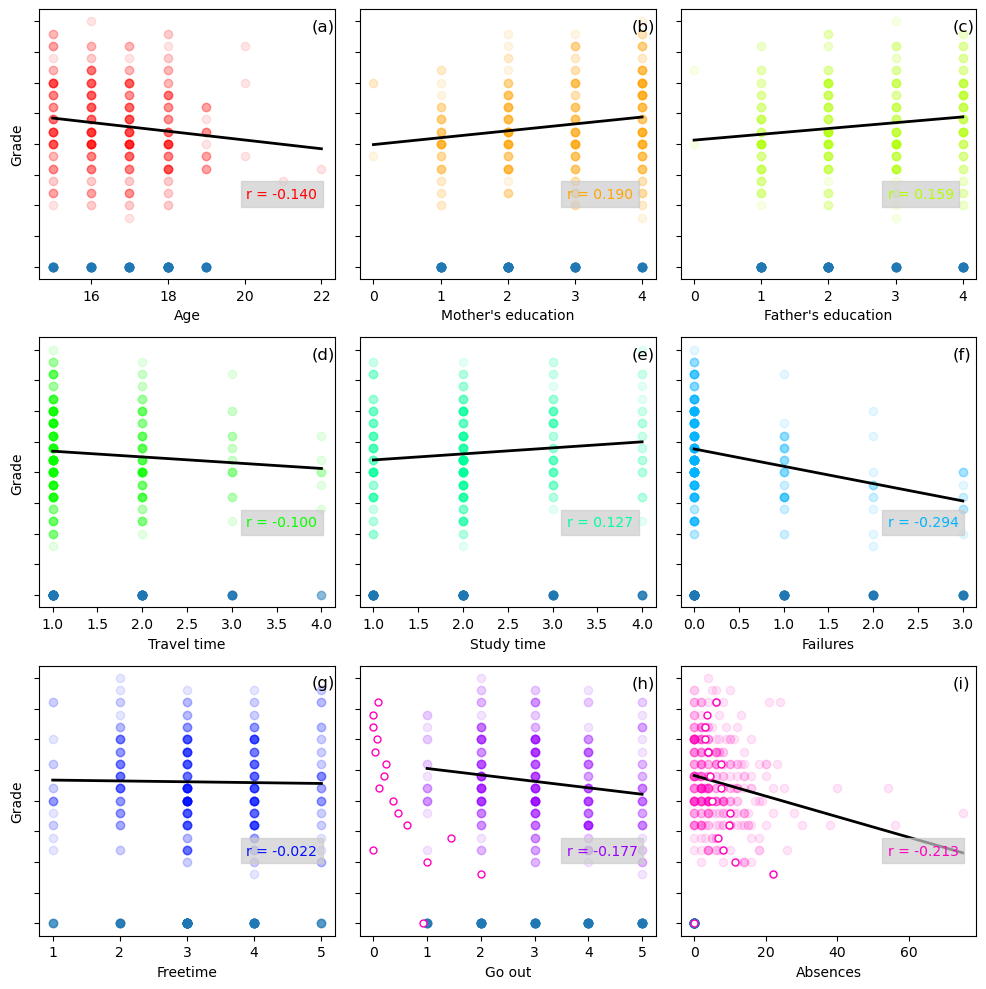

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Correlations amongst main variables.</span></p><br><br>

In [18]:
def plot_descriptive():
    
    fig,axs = plt.subplots( 3, 3, figsize=(10,10), tight_layout=True )
    ivs     = [age, medu, fedu, ttime, stime, fail, ftime, go, absent]
    colors = [cm.hsv(i/9) for i in range (0,9)]
    
    axx       = [axs[2, 1], axs[2, 2]]
    i_0       = y ==0
    i_high    = y > 0
    
    for ax,x,c in zip(axs.ravel(), ivs, colors):
        ax.scatter( x[i_high], y[i_high], alpha=0.1, color=c )
        plot_regression_line(ax, x[i_high], y[i_high], color='k', ls='-', lw=2)
        r   = corrcoeff(x[i_high], y[i_high])
        ax.text(0.7, 0.3, f'r = {r:.3f}', color=c, transform=ax.transAxes, bbox=dict(color='0.8', alpha=0.7))

    for ax,x,c in zip(axs.ravel(), ivs, colors):
        ax.scatter( x[i_0], y[i_0], alpha=0.5)

    xlabels = 'Age', "Mother's education", "Father's education", 'Travel time', 'Study time', 'Failures', 'Freetime', 'Go out', 'Absences'  
    [ax.set_xlabel(s) for ax,s in zip(axs.flat,xlabels)]
    axs[2, 2].set_xticks([0, 20, 40, 60])
    [ax.set_ylabel('Grade') for ax in axs[:,0]]
    for a, s in zip(axs.flat, xlabels):
        a.set_yticklabels([])
    
    [axs[2, 1].plot(fail[y==q].mean(), q, 'o', color=c, mfc='w', ms=5)  for q in range (0, 19)]
    [axs[2, 2].plot(absent[y==q].mean(), q, 'o', color=c, mfc='w', ms=5)  for q in range (0, 19)]

    panel_labels = 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i'
    [ax.text(0.92, 0.92, f'({s})', size=12, transform=ax.transAxes)  for ax,s in zip(axs.ravel(), panel_labels)]
    plt.show()
    
    display_title('Correlations amongst main variables.', pref='Figure', num=1)


plot_descriptive()